### compute trends in 2m air temperature CESM2-4p2z model runs for SSP3-7.0, SSP2-4.5, and SSP1-2.6

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import os
from glob import glob
from collections import OrderedDict
import xarray as xr
import numpy as np

import ncar_jobqueue
from dask.distributed import Client

import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
from scipy import stats
import pop_tools 
import pandas as pd
import cftime
import matplotlib.colors as colors
import utils

### First do SSP3-7.0

In [2]:
case = 'b.e21p4.BSSP370.f09_g17.4p2z.002'
path = '/glade/campaign/cesm/development/bgcwg/projects/CESM2-4p2z-CMIP6-like-run/' + case + '/atm/proc/tseries/month_1/'

In [3]:
path

'/glade/campaign/cesm/development/bgcwg/projects/CESM2-4p2z-CMIP6-like-run/b.e21p4.BSSP370.f09_g17.4p2z.002/atm/proc/tseries/month_1/'

###  grab desired variables

In [4]:
variables = ['TREFHT']

### define the data range

In [5]:
ds = xr.Dataset()

for var in variables:
    
    print('starting on ', var)
    
    files = sorted(glob(f'{path}/{case}.cam.h0.{var}.??????-??????.nc'))  
    
    ds_tmp = xr.open_mfdataset(files, data_vars="minimal", coords='minimal', compat="override", 
                               parallel=True, concat_dim="time", combine='nested', decode_times=True)
    
    ds = xr.merge([ds,ds_tmp],combine_attrs='override')

starting on  TREFHT


In [6]:
ds

<xarray.Dataset>
Dimensions:       (ilev: 33, lat: 192, lev: 32, lon: 288, nbnd: 2, time: 1032)
Coordinates:
  * lat           (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon           (lon) float64 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * lev           (lev) float64 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
  * time          (time) object 2015-02-01 00:00:00 ... 2101-01-01 00:00:00
Dimensions without coordinates: nbnd
Data variables: (12/26)
    gw            (lat) float64 dask.array<chunksize=(192,), meta=np.ndarray>
    hyam          (lev) float64 dask.array<chunksize=(32,), meta=np.ndarray>
    hybm          (lev) float64 dask.array<chunksize=(32,), meta=np.ndarray>
    P0            float64 ...
    hyai          (ilev) float64 dask.array<chunksize=(33,), meta=np.ndarray>
    hybi          (ilev) float64 dask.array<chunksize=(33,), meta=np.ndarray>
    ...            ...
    n2ovmr        (time) float64 dask.array<chunksize=(600,), meta=np.ndarray>
    f11vmr        (time) float64 dask.array<chunksize=(600,), meta=np.ndarray>
    f12vmr        (time) float64 dask.array<chunksize=(600,), meta=np.ndarray>
    sol_tsi       (time) float64 dask.array<chunksize=(600,), meta=np.ndarray>
    nsteph        (time) int32 dask.array<chunksize=(600,), meta=np.ndarray>
    TREFHT        (time, lat, lon) float32 dask.array<chunksize=(600, 192, 288), meta=np.ndarray>

In [7]:
def get_ClusterClient():
    import dask
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client
    cluster = PBSCluster(
        cores=2,
        memory='20 GB',
        processes=1,
        queue='casper',
        resource_spec='select=1:ncpus=1:mem=20GB',
        project='NCGD0011',
        walltime='05:00:00',
        interface='ext',)

    dask.config.set({
        'distributed.dashboard.link':
        'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
    })
    client = Client(cluster)
    return cluster, client

In [8]:
cluster, client = get_ClusterClient()
cluster.scale(18) 
client

Client Scheduler: tcp://128.117.208.173:36739 Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/42227/status,Cluster Workers: 0 Cores: 0 Memory: 0 B


In [9]:
ds["time_bnds"]

<xarray.DataArray 'time_bnds' (time: 1032, nbnd: 2)>
dask.array<concatenate, shape=(1032, 2), dtype=object, chunksize=(600, 2), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 2015-02-01 00:00:00 ... 2101-01-01 00:00:00
Dimensions without coordinates: nbnd
Attributes:
    long_name:  time interval endpoints

In [10]:
ds["time"] = ds.time_bnds.compute().mean(dim="nbnd")

In [11]:
ds.time

<xarray.DataArray 'time' (time: 1032)>
array([cftime.DatetimeNoLeap(2015, 1, 16, 12, 0, 0, 0),
       cftime.DatetimeNoLeap(2015, 2, 15, 0, 0, 0, 0),
       cftime.DatetimeNoLeap(2015, 3, 16, 12, 0, 0, 0), ...,
       cftime.DatetimeNoLeap(2100, 10, 16, 12, 0, 0, 0),
       cftime.DatetimeNoLeap(2100, 11, 16, 0, 0, 0, 0),
       cftime.DatetimeNoLeap(2100, 12, 16, 12, 0, 0, 0)], dtype=object)
Coordinates:
  * time     (time) object 2015-01-16 12:00:00 ... 2100-12-16 12:00:00

In [12]:
ds_ann = ds.resample({'time':'A'}).mean(dim='time').compute()

In [13]:
ds_ann['time'] = np.arange(2015,2101,1)

In [14]:
da = ds_ann.TREFHT

coeffs = da.polyfit('time', deg=1)

In [15]:
temp_trends_ssp370 = coeffs.polyfit_coefficients.isel(degree=0)

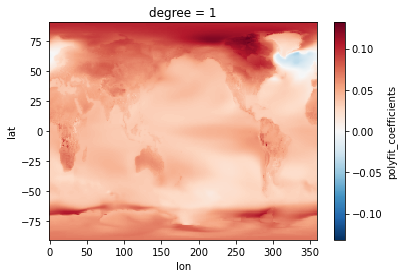

In [16]:
temp_trends_ssp370.plot()

### Make a map

Since this threshold was derived for an albatross species, it would make sense to mask continents in white and display only ocean (SST) values. The idea would be a simple two-color (or two-tone) map: for example, warm colors (red/orange) for extinction and cool colors (green/blue) for rescue.

- Areas where the temperature trend is greater than 0.0105 °C/year would correspond to population extinction.
- Areas where the trend is below this threshold would correspond to evolutionary rescue.

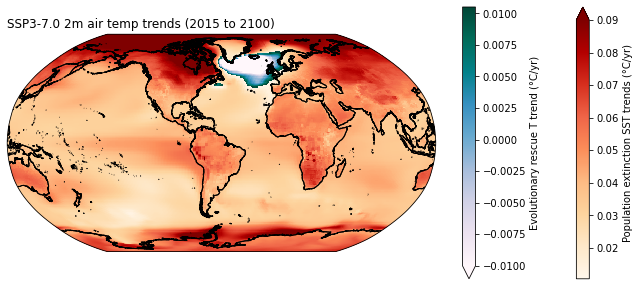

In [35]:
fig = plt.figure(figsize=(12,5))

############### 
ax = fig.add_subplot(1,1,1, projection=ccrs.Robinson(central_longitude=305.0))
#ax.set_extent([-180, 180, -90, -30], ccrs.PlateCarree())
ax.set_title('SSP3-7.0 2m air temp trends (2015 to 2100)', loc='left')

pc = ax.pcolormesh(temp_trends_ssp370.lon,temp_trends_ssp370.lat,temp_trends_ssp370.where(temp_trends_ssp370>0.0105),
                    transform=ccrs.PlateCarree(),cmap='OrRd',
                   vmin=0.0105,vmax=0.09)


ax.coastlines('10m',linewidth=1)
fig.colorbar(pc,extend='max', label='Population extinction SST trends (°C/yr)');

pc = ax.pcolormesh(temp_trends_ssp370.lon,temp_trends_ssp370.lat,temp_trends_ssp370.where(temp_trends_ssp370<0.0105),
                    transform=ccrs.PlateCarree(),cmap='PuBuGn',
                   vmin=-0.01,vmax=0.0105)


ax.coastlines('10m',linewidth=1)
fig.colorbar(pc,extend='min', label='Evolutionary rescue T trend (°C/yr)');

fig.savefig('/glade/work/kristenk/figs/AirTemp2m_trends_SSP370.png', bbox_inches='tight', dpi=300, format='png');

### Get SSP 2-4.5

In [18]:
case = 'b.e21p4.BSSP245.f09_g17.4p2z.002'
path = '/glade/campaign/cesm/development/bgcwg/projects/CESM2-4p2z-CMIP6-like-run/' + case + '/atm/proc/tseries/month_1/'

In [19]:
ds = xr.Dataset()

for var in variables:
    
    print('starting on ', var)
    
    files = sorted(glob(f'{path}/{case}.cam.h0.{var}.??????-??????.nc'))  
    
    ds_tmp = xr.open_mfdataset(files, data_vars="minimal", coords='minimal', compat="override", 
                               parallel=True, concat_dim="time", combine='nested', decode_times=True)
    
    ds = xr.merge([ds,ds_tmp],combine_attrs='override')

starting on  TREFHT


In [20]:
ds["time"] = ds.time_bnds.compute().mean(dim="nbnd")

In [21]:
ds_ann = ds.resample({'time':'A'}).mean(dim='time').compute()

In [22]:
ds_ann['time'] = np.arange(2015,2101,1)

In [23]:
da = ds_ann.TREFHT

coeffs = da.polyfit('time', deg=1)

In [24]:
temp_trends_ssp245 = coeffs.polyfit_coefficients.isel(degree=0)

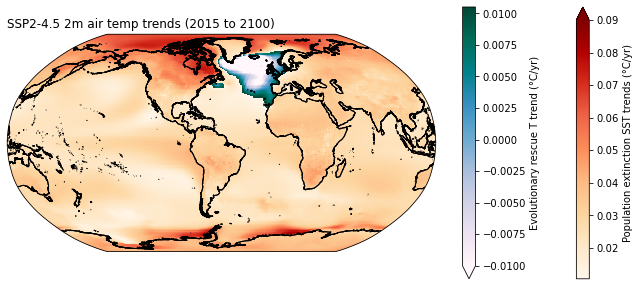

In [36]:
fig = plt.figure(figsize=(12,5))

############### 
ax = fig.add_subplot(1,1,1, projection=ccrs.Robinson(central_longitude=305.0))
#ax.set_extent([-180, 180, -90, -30], ccrs.PlateCarree())
ax.set_title('SSP2-4.5 2m air temp trends (2015 to 2100)', loc='left')

pc = ax.pcolormesh(temp_trends_ssp245.lon,temp_trends_ssp245.lat,temp_trends_ssp245.where(temp_trends_ssp245>0.0105),
                    transform=ccrs.PlateCarree(),cmap='OrRd',
                   vmin=0.0105,vmax=0.09)


ax.coastlines('10m',linewidth=1)
fig.colorbar(pc,extend='max', label='Population extinction SST trends (°C/yr)');

pc = ax.pcolormesh(temp_trends_ssp245.lon,temp_trends_ssp245.lat,temp_trends_ssp245.where(temp_trends_ssp245<0.0105),
                    transform=ccrs.PlateCarree(),cmap='PuBuGn',
                   vmin=-0.01,vmax=0.0105)


ax.coastlines('10m',linewidth=1)
fig.colorbar(pc,extend='min', label='Evolutionary rescue T trend (°C/yr)');

fig.savefig('/glade/work/kristenk/figs/AirTemp2m_trends_SSP245.png', bbox_inches='tight', dpi=300, format='png');

### Get SSP1-2.6

In [37]:
case = 'b.e21p4.BSSP126.f09_g17.4p2z.002'
path = '/glade/campaign/cesm/development/bgcwg/projects/CESM2-4p2z-CMIP6-like-run/' + case + '/atm/proc/tseries/month_1/'

In [38]:
ds = xr.Dataset()

for var in variables:
    
    print('starting on ', var)
    
    files = sorted(glob(f'{path}/{case}.cam.h0.{var}.??????-??????.nc'))  
    
    ds_tmp = xr.open_mfdataset(files, data_vars="minimal", coords='minimal', compat="override", 
                               parallel=True, concat_dim="time", combine='nested', decode_times=True)
    
    ds = xr.merge([ds,ds_tmp],combine_attrs='override')

starting on  TREFHT


In [39]:
ds["time"] = ds.time_bnds.compute().mean(dim="nbnd")

In [40]:
ds_ann = ds.resample({'time':'A'}).mean(dim='time').compute()

In [41]:
ds_ann['time'] = np.arange(2015,2101,1)

In [42]:
da = ds_ann.TREFHT

coeffs = da.polyfit('time', deg=1)

In [43]:
temp_trends_ssp126 = coeffs.polyfit_coefficients.isel(degree=0)

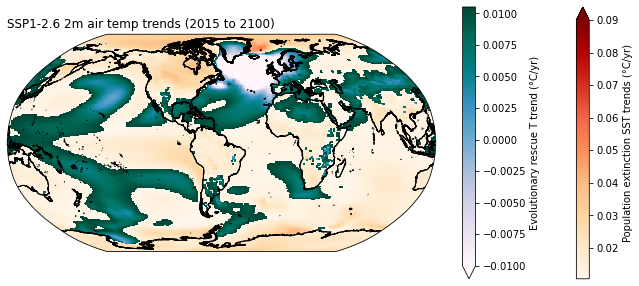

In [44]:
fig = plt.figure(figsize=(12,5))

############### 
ax = fig.add_subplot(1,1,1, projection=ccrs.Robinson(central_longitude=305.0))
#ax.set_extent([-180, 180, -90, -30], ccrs.PlateCarree())
ax.set_title('SSP1-2.6 2m air temp trends (2015 to 2100)', loc='left')

pc = ax.pcolormesh(temp_trends_ssp126.lon,temp_trends_ssp126.lat,temp_trends_ssp126.where(temp_trends_ssp126>0.0105),
                    transform=ccrs.PlateCarree(),cmap='OrRd',
                   vmin=0.0105,vmax=0.09)


ax.coastlines('10m',linewidth=1)
fig.colorbar(pc,extend='max', label='Population extinction SST trends (°C/yr)');

pc = ax.pcolormesh(temp_trends_ssp126.lon,temp_trends_ssp126.lat,temp_trends_ssp126.where(temp_trends_ssp126<0.0105),
                    transform=ccrs.PlateCarree(),cmap='PuBuGn',
                   vmin=-0.01,vmax=0.0105)


ax.coastlines('10m',linewidth=1)
fig.colorbar(pc,extend='min', label='Evolutionary rescue T trend (°C/yr)');

fig.savefig('/glade/work/kristenk/figs/AirTemp2m_trends_SSP126.png', bbox_inches='tight', dpi=300, format='png');

### Put all three maps together

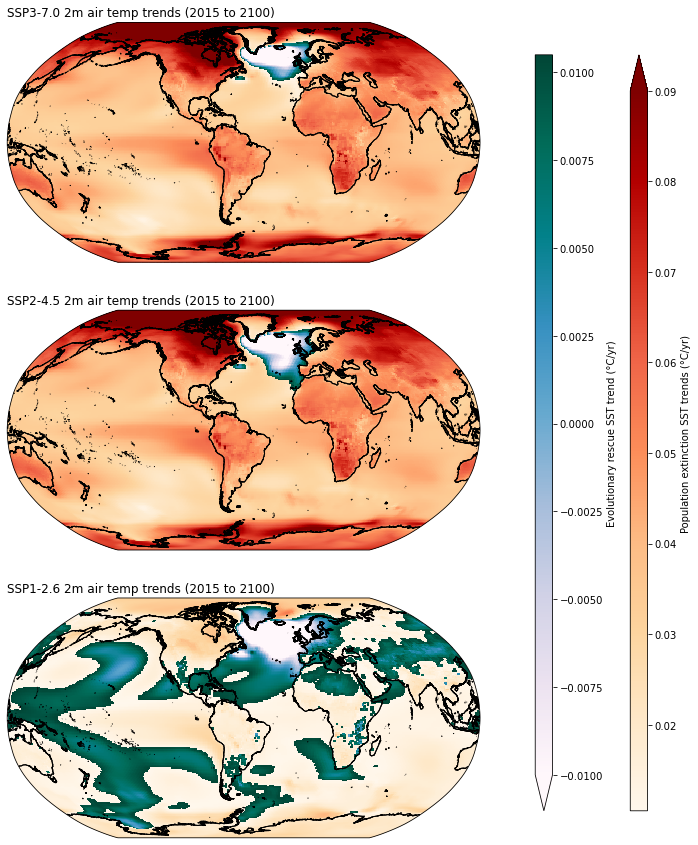

In [46]:
fig = plt.figure(figsize=(12,15))

lon = temp_trends_ssp370.lon
lat = temp_trends_ssp370.lat

max_temp_trend = 0.09


############### 
ax = fig.add_subplot(3,1,1, projection=ccrs.Robinson(central_longitude=305.0))
#ax.set_extent([-180, 180, -90, -30], ccrs.PlateCarree())
ax.set_title('SSP3-7.0 2m air temp trends (2015 to 2100)', loc='left')

pc1 = ax.pcolormesh(lon,lat,temp_trends_ssp370.where(temp_trends_ssp370>0.0105),
                    transform=ccrs.PlateCarree(),cmap='OrRd',
                   vmin=0.0105,vmax=max_temp_trend)

ax.coastlines('10m',linewidth=1)

pc2 = ax.pcolormesh(lon,lat,temp_trends_ssp370.where(temp_trends_ssp370<=0.0105),
                    transform=ccrs.PlateCarree(),cmap='PuBuGn',
                   vmin=-0.01,vmax=0.0105)


ax.coastlines('10m',linewidth=1)

############### 
ax = fig.add_subplot(3,1,2, projection=ccrs.Robinson(central_longitude=305.0))
#ax.set_extent([-180, 180, -90, -30], ccrs.PlateCarree())
ax.set_title('SSP2-4.5 2m air temp trends (2015 to 2100)', loc='left')

pc1 = ax.pcolormesh(lon,lat,temp_trends_ssp370.where(temp_trends_ssp370>0.0105),
                    transform=ccrs.PlateCarree(),cmap='OrRd',
                   vmin=0.0105,vmax=max_temp_trend)


ax.coastlines('10m',linewidth=1)

pc2 = ax.pcolormesh(lon,lat,temp_trends_ssp245.where(temp_trends_ssp245<=0.0105),
                    transform=ccrs.PlateCarree(),cmap='PuBuGn',
                   vmin=-0.01,vmax=0.0105)


ax.coastlines('10m',linewidth=1)

############### 
ax = fig.add_subplot(3,1,3, projection=ccrs.Robinson(central_longitude=305.0))
#ax.set_extent([-180, 180, -90, -30], ccrs.PlateCarree())
ax.set_title('SSP1-2.6 2m air temp trends (2015 to 2100)', loc='left')

pc1 = ax.pcolormesh(lon,lat,temp_trends_ssp126.where(temp_trends_ssp126>0.0105),
                    transform=ccrs.PlateCarree(),cmap='OrRd',
                   vmin=0.0105,vmax=max_temp_trend)

ax.coastlines('10m',linewidth=1)

pc2 = ax.pcolormesh(lon,lat,temp_trends_ssp126.where(temp_trends_ssp126<=0.0105),
                    transform=ccrs.PlateCarree(),cmap='PuBuGn',
                   vmin=-0.01,vmax=0.0105)


ax.coastlines('10m',linewidth=1)

#################
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.80, 0.15, 0.02, 0.7])
cbar1 = fig.colorbar(pc2, cax=cbar_ax,extend='min',label='Evolutionary rescue SST trend (°C/yr)')

#################
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
cbar1 = fig.colorbar(pc1, cax=cbar_ax,extend='max',label='Population extinction SST trends (°C/yr)')

fig.savefig('/glade/work/kristenk/figs/AirTemp2m_trends_all3_SSPs.png', bbox_inches='tight', dpi=300, format='png');